# Hackalysis : Open Source Repository Analysis


*Author: Eisha Tir Raazia*

In [ ]:
import glob
import json
from dotenv import load_dotenv
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

load_dotenv()



def gather_repository_information(DATA_ROOT):
    data_dir = DATA_ROOT
# 1) Get all sub-directories inside data/
    repo_dirs = [d for d in glob.glob(str(data_dir / "*/"))]

# 2) Collect all *_github_repo_metadata.json files from those directories
    json_files = []
    for repo_dir in repo_dirs:
        json_files.extend(glob.glob(str(Path(repo_dir) / "**/*_github_repo_metadata.json"), recursive=True))

    #print(f"Found {len(repo_dirs)} directories")

# 3) Load and merge JSON content into rows
    frames = []

    for file_path in json_files:
        with open(file_path, "r", encoding="utf-8") as f:
            payload = json.load(f)

    # Expected shape: {repo_url: {field: value, ...}, ...}
        if isinstance(payload, dict) and all(isinstance(v, dict) for v in payload.values()):
            chunk_df = pd.DataFrame.from_dict(payload, orient="index")
            chunk_df.index.name = "repo_url"
            frames.append(chunk_df)
        else:
            print(f"Skipping unexpected JSON shape in: {file_path}")

# 4) Build one merged dataframe (index = repo_url, columns = metadata fields)
    repo_metadata_df = (
    pd.concat(frames, axis=0, sort=False)
    .loc[lambda d: ~d.index.duplicated(keep="last")]
    .sort_index()
    )
    
    return repo_dirs,json_files,repo_metadata_df


def get_project_data_paths(DATA_ROOT, provider_prefix: str = "lauzhack"):
    project_dirs = [
        folder for folder in sorted(DATA_ROOT.glob(f"{provider_prefix}-*"))
        if folder.is_dir()
    ]

    parquet_files = []
    for folder in project_dirs:
        projects_path = folder / f"{provider_prefix}_projects.parquet"
        github_projects_path = folder / f"{provider_prefix}_github_project_metadata.parquet"

        if github_projects_path.exists():
            parquet_files.append(github_projects_path)
        elif projects_path.exists():
            parquet_files.append(projects_path)

    return project_dirs, parquet_files


def _normalize_social_links(v):
    if v is None:
        return None
    if isinstance(v, str):
        return v.strip() or None
    if isinstance(v, list):
        cleaned = [str(x).strip() for x in v if str(x).strip()]
        return cleaned if cleaned else None
    if isinstance(v, dict):
        cleaned = {str(k): str(val).strip() for k, val in v.items() if str(val).strip()}
        return cleaned if cleaned else None
    return str(v).strip() or None


def _load_hackathon_metadata_row(metadata_json_path: Path, year: int) -> dict:
    metadata = json.loads(metadata_json_path.read_text(encoding="utf-8"))
    if isinstance(metadata, list):
        metadata = metadata[0] if metadata else {}
    if not isinstance(metadata, dict):
        metadata = {}

    row = {}
    for k, v in metadata.items():
        key = k if str(k).startswith("hackathon_") else f"hackathon_{k}"
        if str(k).lower().strip() in {
            "social", "socials", "social_link", "social_links",
            "hackathon_social_link", "hackathon_social_links"
        }:
            row["hackathon_social_links"] = _normalize_social_links(v)
        else:
            row[key] = v

    row["hackathon_year"] = year
    return row


def load_projects_analysis_ready(data_root: Path, provider_prefix: str = "lauzhack") -> pd.DataFrame:
    frames = []

    for folder in sorted(data_root.glob(f"{provider_prefix}-*")):
        if not folder.is_dir():
            continue

        year_str = folder.name.split("-")[-1]
        if not year_str.isdigit():
            continue
        year = int(year_str)

        projects_path = folder / f"{provider_prefix}_projects.parquet"
        github_projects_path = folder / f"{provider_prefix}_github_project_metadata.parquet"
        metadata_json_path = folder / f"{provider_prefix}_metadata.json"

        if not projects_path.exists() or not metadata_json_path.exists():
            continue

        source_path = github_projects_path if github_projects_path.exists() else projects_path
        df = pd.read_parquet(source_path).copy()
        df["year"] = year

        metadata_row = _load_hackathon_metadata_row(metadata_json_path, year)
        for col, val in metadata_row.items():
            if isinstance(val, (list, dict, tuple, set)):
                df[col] = [val for _ in range(len(df))]
            else:
                df[col] = val

        frames.append(df)

    if not frames:
        return pd.DataFrame()

    merged = pd.concat(frames, ignore_index=True)

    if "github_repo_urls" not in merged.columns:
        merged["github_repo_urls"] = [[] for _ in range(len(merged))]
    if "github_repos_metadata" not in merged.columns:
        merged["github_repos_metadata"] = [[] for _ in range(len(merged))]
    if "github_repo_count" not in merged.columns:
        merged["github_repo_count"] = 0

    merged["github_repo_count"] = pd.to_numeric(
        merged["github_repo_count"], errors="coerce"
    ).fillna(0).astype(int)

    if "project_uid" in merged.columns:
        merged["global_project_uid"] = merged.apply(
            lambda r: f"{provider_prefix}:{int(r['year'])}:{r['project_uid']}"
            if pd.notna(r.get("project_uid"))
            else f"{provider_prefix}:{int(r['year'])}:row:{r.name}",
            axis=1,
        )
    else:
        merged["global_project_uid"] = merged.apply(
            lambda r: f"{provider_prefix}:{int(r['year'])}:row:{r.name}", axis=1
        )

    return merged


def gather_project_information(DATA_ROOT, provider_prefix: str = "lauzhack"):
    project_dirs, parquet_files = get_project_data_paths(DATA_ROOT, provider_prefix)
    project_df = load_projects_analysis_ready(DATA_ROOT, provider_prefix)
    return project_dirs, parquet_files, project_df

## Create Dataset for projects_hackathon analysis and repo_metadata with project foreign key

In [132]:
DATA_ROOT = Path(os.getenv('DATA_ROOT'))

repo_dirs, json_files, repo_metadata_df = gather_repository_information(DATA_ROOT)
project_dirs, parquet_files, project_df = gather_project_information(DATA_ROOT)
repo_metadata_df = repo_metadata_df.reset_index()

In [133]:
print(f"Final project dataframe shape: {project_df.shape}")
print(f"Merged rows for github repositories: {len(repo_metadata_df)}")

display(repo_metadata_df.head(3))
display(project_df.head(3))

Final project dataframe shape: (210, 28)
Merged rows for github repositories: 355


,repo_url,commit_count_default_branch,contributors_count,contributors_top,created_at,default_branch,description,dirs_total_count,files_root_entries,files_total_count,...,readme_title,releases_count,repo,repo_name,stars,topics,updated_at,url,watchers,error
0,https://github.com/22cav/lauzhack2025,21.0,4.0,"[{'contributions': 14, 'html_url': 'https://gi...",2025-11-22T13:18:04Z,lauzhack2025,Control Blender in real-time with hand gestures,19.0,"[{'path': '.gitignore', 'size': 485, 'type': '...",76.0,...,Gesture Control System,0.0,lauzhack2025,3DX,4.0,"[blender-addon, gesture-recognition, landmarks]",2025-11-25T19:56:45Z,https://github.com/22cav/3DX,0.0,NaN
1,https://github.com/4cademy/I.R.I.S._LauzHack_2024,41.0,4.0,"[{'contributions': 24, 'html_url': 'https://gi...",2024-11-30T13:21:59Z,main,Our project for the Vitol challenge at LauzHac...,1.0,"[{'path': '.DS_Store', 'size': 6148, 'type': '...",13.0,...,IRIS - Intelligent Recognition & Image Search,0.0,I.R.I.S._LauzHack_2024,IRIS,2.0,[],2024-12-15T22:55:06Z,https://github.com/4cademy/IRIS,1.0,NaN
2,https://github.com/ALIANTE-IoT/ALIANTE,29.0,5.0,"[{'contributions': 13, 'html_url': 'https://gi...",2025-11-22T11:25:55Z,main,A distributed system for automated biodiversit...,24.0,"[{'path': '.gitignore', 'size': 2251, 'type': ...",73.0,...,ALIANTE,0.0,ALIANTE,ALIANTE,0.0,[],2025-11-25T13:45:32Z,https://github.com/ALIANTE-IoT/ALIANTE,0.0,NaN


,id,title,description,url,team,tags,image_url,awards,categories,hackathon_name,...,github_repos_metadata,year,hackathon_source_url,hackathon_description,hackathon_date,hackathon_date_start,hackathon_date_end,hackathon_social_links,hackathon_extracted_at,global_project_uid
0,1,"SightSync, a virtual assistant for visual impa...",An app that describes the surroundings through...,https://github.com/sightsync,"[""Oriol Agost Batalla"", ""Ferran Aran""]",[],None,"[""1st place overall""]","[""1st place overall""]",LauzHack 2023,...,"[{""input_url"": ""https://github.com/sightsync/....",2023,https://2023.lauzhack.com/,"Student-run hackathon at EPFL, Switzerland",December 2-3,2023-12-02,2023-12-03,{'linkedin': 'https://linkedin.com/in/tatiana-...,2026-03-16T14:48:23.256605,lauzhack:2023:id:1
1,2,VirtuWheel,Real city driving simulator with hand pose rec...,https://github.com/alvaro-budria/VirtuWheel,"[""Jaume Ros Alonso""]",[],None,"[""2nd place overall""]","[""2nd place overall""]",LauzHack 2023,...,"[{""input_url"": ""https://github.com/alvaro-budr...",2023,https://2023.lauzhack.com/,"Student-run hackathon at EPFL, Switzerland",December 2-3,2023-12-02,2023-12-03,{'linkedin': 'https://linkedin.com/in/tatiana-...,2026-03-16T14:48:23.256605,lauzhack:2023:id:2
2,3,It’s not about winning,"""It’s not about winning"" is a cutting-edge app...",https://fastmaildassdas.retool.com/apps/92b217...,"[""Indira Fömmel"", ""Leonard Eyer"", ""Gero Embser""]",[],None,"[""3rd place overall"", ""AXA challenge winner""]","[""3rd place overall"", ""AXA challenge winner""]",LauzHack 2023,...,[],2023,https://2023.lauzhack.com/,"Student-run hackathon at EPFL, Switzerland",December 2-3,2023-12-02,2023-12-03,{'linkedin': 'https://linkedin.com/in/tatiana-...,2026-03-16T14:48:23.256605,lauzhack:2023:id:3


## Dataset Exploration & Preprocessing / EDA

In [24]:
repo_metadata_df

,repo_url,commit_count_default_branch,contributors_count,contributors_top,created_at,default_branch,description,dirs_total_count,files_root_entries,files_total_count,...,readme_title,releases_count,repo,repo_name,stars,topics,updated_at,url,watchers,error
0,https://github.com/22cav/lauzhack2025,21.0,4.0,"[{'contributions': 14, 'html_url': 'https://gi...",2025-11-22T13:18:04Z,lauzhack2025,Control Blender in real-time with hand gestures,19.0,"[{'path': '.gitignore', 'size': 485, 'type': '...",76.0,...,Gesture Control System,0.0,lauzhack2025,3DX,4.0,"[blender-addon, gesture-recognition, landmarks]",2025-11-25T19:56:45Z,https://github.com/22cav/3DX,0.0,NaN
1,https://github.com/4cademy/I.R.I.S._LauzHack_2024,41.0,4.0,"[{'contributions': 24, 'html_url': 'https://gi...",2024-11-30T13:21:59Z,main,Our project for the Vitol challenge at LauzHac...,1.0,"[{'path': '.DS_Store', 'size': 6148, 'type': '...",13.0,...,IRIS - Intelligent Recognition & Image Search,0.0,I.R.I.S._LauzHack_2024,IRIS,2.0,[],2024-12-15T22:55:06Z,https://github.com/4cademy/IRIS,1.0,NaN
2,https://github.com/ALIANTE-IoT/ALIANTE,29.0,5.0,"[{'contributions': 13, 'html_url': 'https://gi...",2025-11-22T11:25:55Z,main,A distributed system for automated biodiversit...,24.0,"[{'path': '.gitignore', 'size': 2251, 'type': ...",73.0,...,ALIANTE,0.0,ALIANTE,ALIANTE,0.0,[],2025-11-25T13:45:32Z,https://github.com/ALIANTE-IoT/ALIANTE,0.0,NaN
3,https://github.com/AaronDinesh/lauzhack-2025,109.0,4.0,"[{'contributions': 49, 'html_url': 'https://gi...",2025-11-22T10:46:30Z,main,NaN,19.0,"[{'path': '.gitignore', 'size': 5201, 'type': ...",66.0,...,NaN,0.0,lauzhack-2025,lauzhack-2025,2.0,[],2025-11-27T19:23:09Z,https://github.com/AaronDinesh/lauzhack-2025,0.0,NaN
4,https://github.com/Akbermet-Toktobekova/Lauz_h...,9.0,2.0,"[{'contributions': 8, 'html_url': 'https://git...",2025-11-22T20:56:29Z,main,NaN,17.0,"[{'path': '.gitignore', 'size': 953, 'type': '...",123.0,...,Fraud Detection & AML Risk Assessment System,0.0,Lauz_hack_2025,Lauz_hack_2025,1.0,[],2025-12-24T01:47:07Z,https://github.com/Akbermet-Toktobekova/Lauz_h...,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350,https://github.com/walid-as/sbb-ghost-rider,4.0,2.0,"[{'contributions': 3, 'html_url': 'https://git...",2025-11-22T14:51:40Z,main,LauzHack challenge 2025:,34.0,"[{'path': '.gitignore', 'size': 225, 'type': '...",69.0,...,GhostRider - Anonymous Ticket System,0.0,sbb-ghost-rider,sbb-ghost-rider,0.0,[],2025-11-23T11:10:03Z,https://github.com/walid-as/sbb-ghost-rider,0.0,NaN
351,https://github.com/wesleymth/LauzHack2023-Auto...,65.0,4.0,"[{'contributions': 30, 'html_url': 'https://gi...",2023-05-14T20:39:18Z,main,NaN,1.0,"[{'path': '.gitignore', 'size': 3151, 'type': ...",23.0,...,speaker-notes,0.0,LauzHack2023-AutoNote,LauzHack2023-SpeakerNotes,1.0,[],2023-12-04T17:08:53Z,https://github.com/wesleymth/LauzHack2023-Spea...,1.0,NaN
352,https://github.com/wesleymth/Lauzhack-2024-Cou...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Lauzhack-2024-Counting-Stuff,NaN,NaN,NaN,NaN,NaN,NaN,"[{'type': 'NOT_FOUND', 'path': ['repository'],..."
353,https://github.com/youssefouru/LauzHack,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,LauzHack,NaN,NaN,NaN,NaN,NaN,NaN,"[{'type': 'NOT_FOUND', 'path': ['repository'],..."


### Preprocess Projects data frame

In [ ]:

def _canonicalize(v):
    if v is None:
        return ""

    try:
        if pd.isna(v):
            return ""
    except Exception:
        pass

    if isinstance(v, str):
        s = v.strip()
        if not s:
            return ""
        try:
            v = json.loads(s)
        except Exception:
            return s

    if isinstance(v, dict):
        return json.dumps(v, ensure_ascii=False, sort_keys=True)

    if isinstance(v, (list, tuple, set)):
        items = [str(x).strip() for x in v if x is not None and str(x).strip()]
        items = sorted(items)
        return json.dumps(items, ensure_ascii=False)

    return str(v).strip()



def _clean_string_series(series):
    return series.astype("string").fillna("").str.strip()



def _non_empty_string_mask(df, column_name):
    if column_name not in df.columns:
        return pd.Series(False, index=df.index)
    return _clean_string_series(df[column_name]).ne("")



def _apply_canonicalization(df, columns):
    for col in columns:
        if col in df.columns:
            df[col] = df[col].map(_canonicalize)
    return df



def preprocess_project_analysis_df(project_df):
    project_df = project_df.copy()

    canonicalize_columns = [
        "awards",
        "categories",
        "team",
        "github_repo_urls",
        "title",
        "project_title",
    ]
    project_df = _apply_canonicalization(project_df, canonicalize_columns)

    columns_to_drop = []
    duplicate_pairs = [
        ("awards", "categories"),
        ("title", "project_title"),
        ("hackathon_year", "year"),
    ]
    for left_col, right_col in duplicate_pairs:
        if left_col in project_df.columns and right_col in project_df.columns:
            if project_df[left_col].equals(project_df[right_col]):
                columns_to_drop.append(right_col)

    non_analysis_cols = [
        "hackathon_name",
        "hackathon_location",
        "hackathon_source_url",
        "hackathon_description",
        "hackathon_date",
        "hackathon_social_links",
        "hackathon_extracted_at",
        "project_uid",
        "id",
        "project_id",
        "image_url",
        "tags",
    ]
    columns_to_drop.extend(non_analysis_cols)
    columns_to_drop = list(dict.fromkeys(columns_to_drop))

    project_df = project_df.drop(columns=columns_to_drop, errors="ignore")

    for col in ["hackathon_date_start", "hackathon_date_end"]:
        if col in project_df.columns:
            project_df[col] = pd.to_datetime(project_df[col], errors="coerce")

    return project_df, columns_to_drop



def preprocess_repo_metadata_df(repo_metadata_df):
    repo_metadata_df = repo_metadata_df.copy().convert_dtypes()

    date_cols = [
        "created_at",
        "updated_at",
        "pushed_at",
        "first_commit_date_default_branch",
        "last_commit_date_default_branch",
        "latest_release_date",
    ]
    existing_date_cols = [col for col in date_cols if col in repo_metadata_df.columns]

    object_cols = repo_metadata_df.select_dtypes(include=["object"]).columns
    str_cols = repo_metadata_df.select_dtypes(include=["string"]).columns.difference(existing_date_cols)
    bool_cols = repo_metadata_df.select_dtypes(include=["boolean"]).columns
    numeric_columns = repo_metadata_df.select_dtypes(include=["number"]).columns

    if len(str_cols) > 0:
        repo_metadata_df[str_cols] = repo_metadata_df[str_cols].apply(_clean_string_series)

    if len(bool_cols) > 0:
        repo_metadata_df[bool_cols] = repo_metadata_df[bool_cols].fillna(False).astype("boolean")

    if len(numeric_columns) > 0:
        repo_metadata_df[numeric_columns] = repo_metadata_df[numeric_columns].fillna(0).astype("int64")

    if existing_date_cols:
        repo_metadata_df[existing_date_cols] = repo_metadata_df[existing_date_cols].apply(
            pd.to_datetime, errors="coerce"
        )

    repo_metadata_df = repo_metadata_df.drop(columns=["is_private"], errors="ignore")

    summary = {
        "object_columns": object_cols.tolist(),
        "string_columns": str_cols.tolist(),
        "date_columns": existing_date_cols,
        "boolean_columns": bool_cols.tolist(),
        "numeric_columns": numeric_columns.tolist(),
    }
    return repo_metadata_df, summary



def build_repo_analysis_features(df):
    df = df.copy()

    df["has_error"] = _non_empty_string_mask(df, "error")
    df["has_valid_metadata"] = ~df["has_error"] & _non_empty_string_mask(df, "url")
    df["is_linked_project"] = _non_empty_string_mask(df, "project_foreign_key")

    if {"pushed_at", "created_at"}.issubset(df.columns):
        df["repo_age_days"] = (df["pushed_at"] - df["created_at"]).dt.days
    else:
        df["repo_age_days"] = pd.NA

    if {"last_commit_date_default_branch", "first_commit_date_default_branch"}.issubset(df.columns):
        df["active_days_default_branch"] = (
            df["last_commit_date_default_branch"] - df["first_commit_date_default_branch"]
        ).dt.days
    else:
        df["active_days_default_branch"] = pd.NA

    if "commit_count_default_branch" in df.columns:
        commits = pd.to_numeric(df["commit_count_default_branch"], errors="coerce").fillna(0)
        df["commit_log"] = np.log1p(commits)
    else:
        df["commit_log"] = 0.0

    if "stars" in df.columns:
        stars = pd.to_numeric(df["stars"], errors="coerce").fillna(0)
        df["stars_log"] = np.log1p(stars)
    else:
        df["stars_log"] = 0.0

    if "contributors_count" in df.columns:
        contributors = pd.to_numeric(df["contributors_count"], errors="coerce").fillna(0)
        df["contributors_total"] = contributors.astype(int)
        df["contributors_count_log"] = np.log1p(contributors)
    else:
        df["contributors_total"] = 0
        df["contributors_count_log"] = 0.0

    return df



project_df, dropped_project_columns = preprocess_project_analysis_df(project_df)

repo_metadata_df, repo_metadata_summary = preprocess_repo_metadata_df(repo_metadata_df)
repo_metadata_df = build_repo_analysis_features(repo_metadata_df)

print("project_df shape: ", project_df.shape)
print(f"After dropping columns in projects df: \n columns = {len(project_df.columns)} \n sample columns = {project_df.columns}")

print(f"\nRepository metadata df shape: {repo_metadata_df.shape}")
print(f"Repository metadata df columns: {repo_metadata_df.columns}")

In [26]:
print("Object columns:", repo_metadata_summary["object_columns"])
print("String columns:", repo_metadata_summary["string_columns"])
print("Date-like columns:", repo_metadata_summary["date_columns"])
print("Boolean columns:", repo_metadata_summary["boolean_columns"])
print("Numeric columns:", repo_metadata_summary["numeric_columns"])
print("Various data types:\n", repo_metadata_df.dtypes.value_counts())

Object columns: ['contributors_top', 'files_root_entries', 'languages_top', 'topics']
String columns: ['default_branch', 'description', 'error', 'homepage_url', 'last_commit_oid_default_branch', 'latest_release_tag', 'license_name', 'license_spdx', 'name_with_owner', 'owner', 'parent_repo', 'parent_url', 'primary_language', 'project_foreign_key', 'readme_text', 'readme_title', 'repo', 'repo_name', 'repo_url', 'url']
Date-like columns: ['created_at', 'updated_at', 'pushed_at', 'first_commit_date_default_branch', 'last_commit_date_default_branch', 'latest_release_date']
Boolean columns: ['has_ci', 'has_contributing', 'has_docker', 'has_docs', 'has_license_file', 'has_notebooks', 'has_readme_file', 'has_tests', 'is_archived', 'is_fork', 'is_private']
Numeric columns: ['commit_count_default_branch', 'contributors_count', 'dirs_total_count', 'files_total_count', 'forks', 'issues_closed', 'issues_open', 'issues_total', 'pull_requests_closed', 'pull_requests_merged', 'pull_requests_open', 'pu

##### High level summary of data 

In [127]:
linked_project_mask = _non_empty_string_mask(repo_metadata_df, "project_foreign_key")
valid_repo_metadata_mask = (
    _non_empty_string_mask(repo_metadata_df, "url")
    & ~_non_empty_string_mask(repo_metadata_df, "error")
)

repos_with_project_and_metadata = repo_metadata_df[
    linked_project_mask & valid_repo_metadata_mask
].copy()

repos_with_project_and_no_metadata = repo_metadata_df[
    linked_project_mask & ~valid_repo_metadata_mask
].copy()

print(f"total repos: {repo_metadata_df.repo_url.nunique()}\
        \nRepos with linked metadata: {repo_metadata_df.shape[0]-repo_metadata_df.error.nunique(dropna=True)}\
      \nTotal linked Projects: {repo_metadata_df.project_foreign_key.nunique(dropna=True)-1} and total project repo URLs: {len(repos_with_project_and_metadata) + len(repos_with_project_and_no_metadata)}")
print(f"Repos with project_foreign_key and valid GitHub metadata: {len(repos_with_project_and_metadata)}, unique projects: {repos_with_project_and_metadata.project_foreign_key.nunique()}")
print(f"Repos with project_foreign_key but no valid GitHub metadata: {len(repos_with_project_and_no_metadata)}, unique projects: {repos_with_project_and_no_metadata.project_foreign_key.nunique()}")



total repos: 355        
Repos with linked metadata: 326      
Total linked Projects: 194 and total project repo URLs: 213
Repos with project_foreign_key and valid GitHub metadata: 185, unique projects: 167
Repos with project_foreign_key but no valid GitHub metadata: 28, unique projects: 27


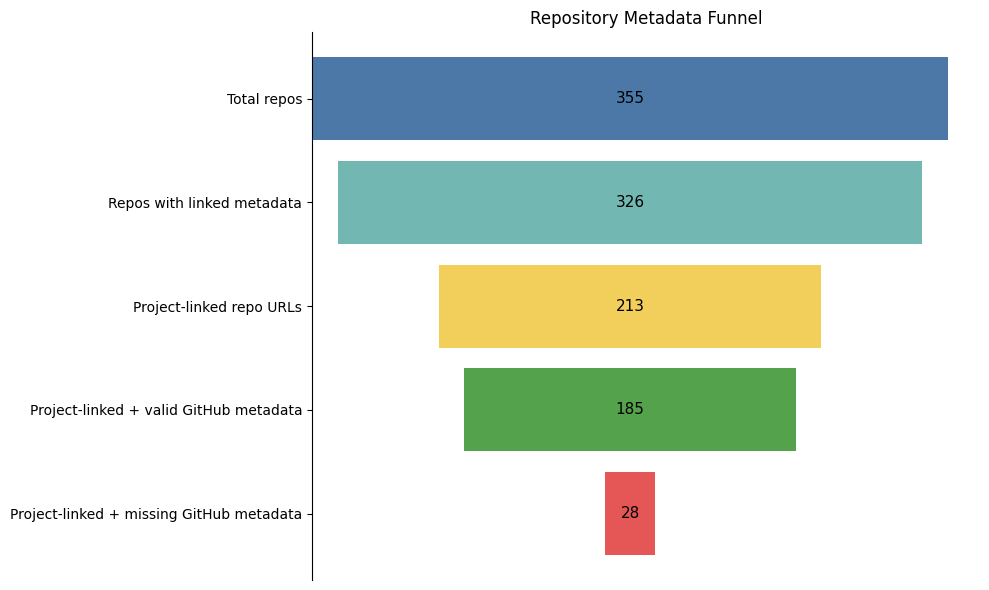

In [128]:
stages = [
    "Total repos",
    "Repos with linked metadata",
    "Project-linked repo URLs",
    "Project-linked + valid GitHub metadata",
    "Project-linked + missing GitHub metadata",
]

values = [355, 326, 213, 185, 28]
max_val = max(values)

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = list(range(len(stages)))[::-1]
left_offsets = [(max_val - v) / 2 for v in values]

ax.barh(
    y_pos,
    values,
    left=left_offsets,
    color=["#4C78A8", "#72B7B2", "#F2CF5B", "#54A24B", "#E45756"]
)

ax.set_yticks(y_pos)
ax.set_yticklabels(stages)
ax.set_title("Repository Metadata Funnel")
ax.set_xticks([])

for y, v, left in zip(y_pos, values, left_offsets):
    ax.text(left + v / 2, y, str(v), ha="center", va="center", color="black", fontsize=11)

for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

#### Create derived columns for analysis

In [ ]:
repo_metadata_df['true_hackathon_repos'] = False

##### Manually label the true hackathon repositories

In [31]:
eisha_repos = repo_metadata_df[
    repo_metadata_df["owner"].astype("string").str.strip().eq("EishaMazhar")
].copy()

print(f"Repositories owned by EishaMazhar: {len(eisha_repos)}")
# print(eisha_repos.repo_url.tolist())

eisha_true_repos = ["CERN-Webfest-Post-Quantum-Cryptography", "Drive-H-er", "Driveher", "open-pulse-quickstart", "cosmos-sdk", "Safe-pooling-2020", "Safe-Pooling", "Manell"]

sdsc_repos = repo_metadata_df[
    repo_metadata_df["owner"].astype("string").str.strip().eq("sdsc-ordes")
].copy()

sdsc_true_repos = ["open-pulse-quickstart", "ordfts-hackathon-vehicles-detection"]
print(f"Repositories owned by sdsc-ordes: {len(sdsc_repos)}")
# print(sdsc_repos.repo_url.tolist())

Repositories owned by EishaMazhar: 69
Repositories owned by sdsc-ordes: 73


In [33]:

# Mark repos as true hackathon repos when project_foreign_key is present (non-empty)
repo_metadata_df["true_hackathon_repos"] = _non_empty_string_mask(
    repo_metadata_df, "project_foreign_key"
).astype(bool)

# Robust repo-name series (avoids KeyError: 'name')
if "name" in repo_metadata_df.columns:
    repo_name_series = repo_metadata_df["name"].astype("string").str.strip()
elif "repo_name" in repo_metadata_df.columns:
    repo_name_series = repo_metadata_df["repo_name"].astype("string").str.strip()
elif "repo" in repo_metadata_df.columns:
    repo_name_series = repo_metadata_df["repo"].astype("string").str.strip()
else:
    repo_name_series = repo_metadata_df["repo_url"].astype("string").str.rstrip("/").str.split("/").str[-1]

owner_series = (
    repo_metadata_df["owner"].astype("string").str.strip()
    if "owner" in repo_metadata_df.columns
    else repo_metadata_df["name_with_owner"].astype("string").str.split("/").str[0].str.strip()
)

repo_metadata_df["true_hackathon_repos"] = (
    repo_metadata_df["true_hackathon_repos"]
    | (
        owner_series.eq("EishaMazhar")
        & repo_name_series.isin(eisha_true_repos)
    )
    | (
        owner_series.eq("sdsc-ordes")
        & repo_name_series.isin(sdsc_true_repos)
    )
)

repo_metadata_df["true_hackathon_repos"].value_counts(dropna=False)

true_hackathon_repos
True     223
False    132
Name: count, dtype: int64[pyarrow]

In [38]:
project_keys_count_gt1 = (
    repo_metadata_df.loc[linked_project_mask]
    .groupby("project_foreign_key")["repo_url"]
    .nunique()
    .loc[lambda s: s > 1]
    .sort_values(ascending=False)
)

# print(project_keys_count_gt1)
# This can further help identify multi-repo projects and only mark tru repos manually out of mutiple repos linked to the same project (task for later)

## EPFL Concepts Enrichment

Use the EPFL Graph / EPFL Concepts API to assign concepts to each repository from its available text fields.

The defaults are intentionally fast for notebook iteration: `max_repos=10`, `max_chars=4000`, `include_readme=False`, `max_tries=2`, `delay_retry=2`.
Increase them only after the small test run looks correct.

Set credentials before running this cell, either by:
- pointing `EPFL_GRAPH_API_JSON` to a local GraphAI credentials JSON file, or
- exporting `EPFL_GRAPH_API_HOST`, `EPFL_GRAPH_API_PORT`, `EPFL_GRAPH_API_USER`, and `EPFL_GRAPH_API_PASSWORD`.

In [ ]:
import tempfile
import time

try:
    from graphai_client.client_api.text import extract_concepts_from_text
    from graphai_client.client_api.utils import login
except ImportError as exc:
    raise ImportError(
        "Install graphai-client first, for example with: uv pip install graphai-client"
    ) from exc

DEFAULT_MAX_REPOS = 10
DEFAULT_MAX_CHARS = 4000
DEFAULT_MAX_TRIES = 2
DEFAULT_DELAY_RETRY = 2
DEFAULT_SLEEP_SECONDS = 0.0
DEFAULT_PROGRESS_EVERY = 20


def _build_graph_api_json_from_env() -> Path | None:
    host = os.getenv("EPFL_GRAPH_API_HOST")
    port = os.getenv("EPFL_GRAPH_API_PORT")
    user = os.getenv("EPFL_GRAPH_API_USER")
    password = os.getenv("EPFL_GRAPH_API_PASSWORD")

    if not all([host, port, user, password]):
        return None

    tmp = tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False)
    json.dump(
        {
            "host": host.rstrip("/"),
            "port": int(port),
            "user": user,
            "password": password,
        },
        tmp,
    )
    tmp.flush()
    tmp.close()
    return Path(tmp.name)


def get_graph_login_info(graph_api_json: str | Path | None = None) -> dict:
    temporary_path = None
    graph_api_json_path = Path(graph_api_json) if graph_api_json else _build_graph_api_json_from_env()
    if graph_api_json_path is None:
        raise RuntimeError(
            "Missing EPFL Graph credentials. Set EPFL_GRAPH_API_JSON or the "
            "EPFL_GRAPH_API_HOST/PORT/USER/PASSWORD env vars."
        )

    if graph_api_json is None:
        temporary_path = graph_api_json_path

    try:
        return login(str(graph_api_json_path))
    finally:
        if temporary_path is not None:
            temporary_path.unlink(missing_ok=True)


def build_repo_concepts_input_df(repo_df: pd.DataFrame) -> pd.DataFrame:
    return repo_df.copy().reset_index(drop=True)


def _coerce_string_list(value):
    if value is None:
        return []

    if isinstance(value, str):
        stripped = value.strip()
        if not stripped:
            return []
        try:
            value = json.loads(stripped)
        except Exception:
            return [stripped]

    if isinstance(value, (list, tuple, set)):
        return [str(item).strip() for item in value if str(item).strip()]

    return [str(value).strip()] if str(value).strip() else []


def build_repo_concept_text(
    row: dict,
    max_chars: int = DEFAULT_MAX_CHARS,
    include_readme: bool = False,
) -> str:
    parts = [
        row.get("repo_name") or row.get("repo"),
        row.get("description"),
        row.get("primary_language"),
    ]

    repo_topics = row.get("repo_topics", row.get("topics"))
    topics = _coerce_string_list(repo_topics)
    if topics:
        parts.append("Topics: " + ", ".join(topics))

    if include_readme:
        readme_text = row.get("readme_text")
        if isinstance(readme_text, str) and readme_text.strip():
            parts.append(readme_text.strip())

    text = "\n\n".join(
        str(part).strip() for part in parts if isinstance(part, str) and part.strip()
    )
    return text[:max_chars]


def assess_repo_concept_query_readiness(
    row: dict,
    *,
    include_readme: bool = False,
    max_chars: int = DEFAULT_MAX_CHARS,
) -> dict:
    repo_name = (row.get("repo_name") or row.get("repo") or "")
    description = row.get("description") or ""
    primary_language = row.get("primary_language") or ""
    topics = _coerce_string_list(row.get("repo_topics", row.get("topics")))
    readme_text = row.get("readme_text") or ""

    has_repo_name = bool(str(repo_name).strip())
    has_description = bool(str(description).strip())
    has_language = bool(str(primary_language).strip())
    has_topics = bool(topics)
    has_readme = bool(include_readme and isinstance(readme_text, str) and readme_text.strip())

    if has_description or has_topics or has_readme:
        reason = "ready"
        should_query = True
    elif has_repo_name and has_language:
        reason = "ready"
        should_query = True
    else:
        reason = "insufficient_repo_metadata"
        should_query = False

    text = build_repo_concept_text(
        row,
        max_chars=max_chars,
        include_readme=include_readme,
    )
    if should_query and not text:
        should_query = False
        reason = "empty_repo_text"

    return {
        "should_query_concepts": should_query,
        "repo_concepts_skip_reason": None if should_query else reason,
        "repo_concept_text": text,
    }


def prepare_repo_concepts_requests(
    repo_df: pd.DataFrame,
    *,
    max_chars: int = DEFAULT_MAX_CHARS,
    include_readme: bool = False,
) -> pd.DataFrame:
    prepared_df = repo_df.copy()
    records = prepared_df.to_dict("records")
    readiness_rows = [
        assess_repo_concept_query_readiness(
            record,
            include_readme=include_readme,
            max_chars=max_chars,
        )
        for record in records
    ]
    readiness_df = pd.DataFrame(readiness_rows, index=prepared_df.index)
    return prepared_df.join(readiness_df)


def extract_repo_concepts_from_text_value(
    text: str,
    login_info: dict,
    *,
    restrict_to_ontology: bool = True,
    max_tries: int = DEFAULT_MAX_TRIES,
    delay_retry: float = DEFAULT_DELAY_RETRY,
) -> dict:
    concepts = []
    error = None

    if text:
        try:
            concepts = extract_concepts_from_text(
                text,
                login_info,
                restrict_to_ontology=restrict_to_ontology,
                max_tries=max_tries,
                delay_retry=delay_retry,
            ) or []
        except Exception as exc:
            error = str(exc)
    else:
        error = "empty_repo_text"

    return {
        "repo_concepts": concepts,
        "repo_concept_names": [
            concept.get("concept_name") for concept in concepts if isinstance(concept, dict)
        ],
        "repo_top_concept": next(
            (concept.get("concept_name") for concept in concepts if isinstance(concept, dict)),
            None,
        ),
        "repo_concepts_error": error,
    }


def add_epfl_concepts_to_repo_df(
    repo_df: pd.DataFrame,
    *,
    graph_api_json: str | Path | None = None,
    max_repos: int | None = DEFAULT_MAX_REPOS,
    max_chars: int = DEFAULT_MAX_CHARS,
    include_readme: bool = False,
    sleep_seconds: float = DEFAULT_SLEEP_SECONDS,
    restrict_to_ontology: bool = True,
    max_tries: int = DEFAULT_MAX_TRIES,
    delay_retry: float = DEFAULT_DELAY_RETRY,
    progress_every: int = DEFAULT_PROGRESS_EVERY,
) -> pd.DataFrame:
    source_df = repo_df.head(max_repos).copy() if max_repos is not None else repo_df.copy()
    source_df = prepare_repo_concepts_requests(
        source_df,
        max_chars=max_chars,
        include_readme=include_readme,
    )

    if not source_df["should_query_concepts"].any():
        source_df["repo_concepts"] = [[] for _ in range(len(source_df))]
        source_df["repo_concept_names"] = [[] for _ in range(len(source_df))]
        source_df["repo_top_concept"] = None
        source_df["repo_concepts_error"] = None
        return source_df

    login_info = get_graph_login_info(graph_api_json=graph_api_json)

    extracted_rows = []
    total_rows = len(source_df)
    processed_queries = 0
    for row_number, record in enumerate(source_df.to_dict("records"), start=1):
        if record.get("should_query_concepts"):
            extracted_rows.append(
                extract_repo_concepts_from_text_value(
                    record.get("repo_concept_text", ""),
                    login_info,
                    restrict_to_ontology=restrict_to_ontology,
                    max_tries=max_tries,
                    delay_retry=delay_retry,
                )
            )
            processed_queries += 1
            if sleep_seconds:
                time.sleep(sleep_seconds)
        else:
            extracted_rows.append(
                {
                    "repo_concepts": [],
                    "repo_concept_names": [],
                    "repo_top_concept": None,
                    "repo_concepts_error": None,
                }
            )

        if progress_every and (row_number % progress_every == 0 or row_number == total_rows):
            print(
                f"Processed {row_number}/{total_rows} repositories "
                f"({processed_queries} queried, {row_number - processed_queries} skipped)"
            )

    concepts_df = pd.DataFrame(extracted_rows, index=source_df.index)
    return source_df.join(concepts_df)


def export_repo_concepts_df(
    repo_df: pd.DataFrame,
    csv_path: Path,
    parquet_path: Path,
) -> None:
    repo_df.to_csv(csv_path, index=False)

    parquet_df = repo_df.copy()
    for col in parquet_df.columns:
        if parquet_df[col].map(lambda value: isinstance(value, (list, dict))).any():
            parquet_df[col] = parquet_df[col].map(
                lambda value: json.dumps(value, ensure_ascii=False)
                if isinstance(value, (list, dict))
                else value
            )
    parquet_df.to_parquet(parquet_path, index=False)


def run_repo_concepts_enrichment(
    repo_df: pd.DataFrame,
    *,
    data_root: Path,
    graph_api_json: str | Path | None = None,
    max_repos: int | None = DEFAULT_MAX_REPOS,
    max_chars: int = DEFAULT_MAX_CHARS,
    include_readme: bool = False,
    sleep_seconds: float = DEFAULT_SLEEP_SECONDS,
    restrict_to_ontology: bool = True,
    max_tries: int = DEFAULT_MAX_TRIES,
    delay_retry: float = DEFAULT_DELAY_RETRY,
    progress_every: int = DEFAULT_PROGRESS_EVERY,
    export_basename: str = "repos_data_with_concepts",
    export: bool = True,
) -> dict:
    repo_concepts_input = build_repo_concepts_input_df(repo_df)

    repo_analysis_with_concepts = add_epfl_concepts_to_repo_df(
        repo_concepts_input,
        graph_api_json=graph_api_json,
        max_repos=max_repos,
        max_chars=max_chars,
        include_readme=include_readme,
        sleep_seconds=sleep_seconds,
        restrict_to_ontology=restrict_to_ontology,
        max_tries=max_tries,
        delay_retry=delay_retry,
        progress_every=progress_every,
    )

    skipped_repos_df = repo_analysis_with_concepts[
        ~repo_analysis_with_concepts["should_query_concepts"]
    ].copy()

    out_csv = data_root / f"{export_basename}.csv" if export else None
    out_parquet = data_root / f"{export_basename}.parquet" if export else None
    if export:
        export_repo_concepts_df(repo_analysis_with_concepts, out_csv, out_parquet)

    return {
        "repo_concepts_input": repo_concepts_input,
        "repo_analysis_with_concepts": repo_analysis_with_concepts,
        "skipped_repos_df": skipped_repos_df,
        "out_csv": out_csv,
        "out_parquet": out_parquet,
    }


valid_repo_df = repo_metadata_df[repo_metadata_df["has_valid_metadata"]].copy()

concept_results = run_repo_concepts_enrichment(
    repo_df=valid_repo_df,
    data_root=DATA_ROOT,
    graph_api_json=os.getenv("EPFL_GRAPH_API_JSON"),
    max_repos=400,
    include_readme=True,
    export=False,
)

concept_cols = [
    "repo_url",
    "should_query_concepts",
    "repo_concepts_skip_reason",
    "repo_concept_text",
    "repo_concepts",
    "repo_concept_names",
    "repo_top_concept",
    "repo_concepts_error",
]

concept_enriched_subset = concept_results["repo_analysis_with_concepts"][concept_cols].copy()

repo_metadata_with_concepts = repo_metadata_df.merge(
    concept_enriched_subset,
    on="repo_url",
    how="left",
)


Processed 20/327 repositories (20 queried, 0 skipped)
Processed 40/327 repositories (39 queried, 1 skipped)
[2026-03-18 01:53:00] [GRAPHAI] [CONCEPT DETECTION] [WARNING] Error 500: Internal Server Error while doing POST on https://graphai.epfl.ch:443/text/wikify?restrict_to_ontology=True&graph_score_smoothing=True&ontology_score_smoothing=True&keywords_score_smoothing=True&normalisation_coef=0.5&filtering_threshold=0.1&filtering_min_votes=5&refresh_scores=True
Processed 60/327 repositories (58 queried, 2 skipped)
[2026-03-18 01:53:04] [GRAPHAI] [CONCEPT DETECTION] [WARNING] Error 500: Internal Server Error while doing POST on https://graphai.epfl.ch:443/text/wikify?restrict_to_ontology=True&graph_score_smoothing=True&ontology_score_smoothing=True&keywords_score_smoothing=True&normalisation_coef=0.5&filtering_threshold=0.1&filtering_min_votes=5&refresh_scores=True
Processed 80/327 repositories (78 queried, 2 skipped)
[2026-03-18 01:56:07] [GRAPHAI] [CONCEPT DETECTION] [WARNING] Error 50

### Export the dataframe

In [ ]:
out_csv = DATA_ROOT / "repo_metadata_with_concepts.csv"
out_parquet = DATA_ROOT / "repo_metadata_with_concepts.parquet"

# export_repo_concepts_df(repo_metadata_with_concepts, out_csv, out_parquet)

In [49]:
repo_metadata_with_concepts.info()

<class 'pandas.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 68 columns):
 #   Column                            Non-Null Count  Dtype              
---  ------                            --------------  -----              
 0   repo_url                          355 non-null    string             
 1   commit_count_default_branch       355 non-null    int64              
 2   contributors_count                355 non-null    int64              
 3   contributors_top                  327 non-null    object             
 4   created_at                        327 non-null    datetime64[us, UTC]
 5   default_branch                    355 non-null    string             
 6   description                       355 non-null    string             
 7   dirs_total_count                  355 non-null    int64              
 8   files_root_entries                327 non-null    object             
 9   files_total_count                 355 non-null    int64              
 10  f

In [78]:
if "repo_metadata_with_concepts" not in globals() or repo_metadata_with_concepts is None:
    repo_metadata_df = pd.read_csv(DATA_ROOT / "repo_metadata_with_concepts.csv").copy().convert_dtypes()
    # For columns that were originally lists/dicts, we can attempt to parse them back from JSON strings
else:
    repo_metadata_df = repo_metadata_with_concepts.copy()

print(repo_metadata_df.info())
repo_metadata_df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 68 columns):
 #   Column                            Non-Null Count  Dtype              
---  ------                            --------------  -----              
 0   repo_url                          355 non-null    string             
 1   commit_count_default_branch       355 non-null    int64              
 2   contributors_count                355 non-null    int64              
 3   contributors_top                  327 non-null    object             
 4   created_at                        327 non-null    datetime64[us, UTC]
 5   default_branch                    355 non-null    string             
 6   description                       355 non-null    string             
 7   dirs_total_count                  355 non-null    int64              
 8   files_root_entries                327 non-null    object             
 9   files_total_count                 355 non-null    int64              
 10  f

,repo_url,commit_count_default_branch,contributors_count,contributors_top,created_at,default_branch,description,dirs_total_count,files_root_entries,files_total_count,...,repo_age_days,has_error,has_valid_metadata,should_query_concepts,repo_concepts_skip_reason,repo_concept_text,repo_concepts,repo_concept_names,repo_top_concept,repo_concepts_error
0,https://github.com/22cav/lauzhack2025,21,4,"[{'contributions': 14, 'html_url': 'https://gi...",2025-11-22 13:18:04+00:00,lauzhack2025,Control Blender in real-time with hand gestures,19,"[{'path': '.gitignore', 'size': 485, 'type': '...",76,...,3.0,False,True,True,NaN,3DX\n\nControl Blender in real-time with hand ...,"[{'concept_id': 1400452, 'concept_name': 'Gest...","[Gesture recognition, Blender (software), Gest...",Gesture recognition,NaN
1,https://github.com/4cademy/I.R.I.S._LauzHack_2024,41,4,"[{'contributions': 24, 'html_url': 'https://gi...",2024-11-30 13:21:59+00:00,main,Our project for the Vitol challenge at LauzHac...,1,"[{'path': '.DS_Store', 'size': 6148, 'type': '...",13,...,15.0,False,True,True,NaN,IRIS\n\nOur project for the Vitol challenge at...,"[{'concept_id': 544592, 'concept_name': 'Requi...","[Requirement, Requirements analysis, Business ...",Requirement,NaN
2,https://github.com/ALIANTE-IoT/ALIANTE,29,5,"[{'contributions': 13, 'html_url': 'https://gi...",2025-11-22 11:25:55+00:00,main,A distributed system for automated biodiversit...,24,"[{'path': '.gitignore', 'size': 2251, 'type': ...",73,...,3.0,False,True,True,NaN,ALIANTE\n\nA distributed system for automated ...,"[{'concept_id': 669675, 'concept_name': 'Clust...","[Cluster analysis, Image segmentation, Cloud s...",Cluster analysis,NaN
3,https://github.com/AaronDinesh/lauzhack-2025,109,4,"[{'contributions': 49, 'html_url': 'https://gi...",2025-11-22 10:46:30+00:00,main,,19,"[{'path': '.gitignore', 'size': 5201, 'type': ...",66,...,5.0,False,True,True,NaN,lauzhack-2025\n\nPython,"[{'concept_id': 18942, 'concept_name': 'Monty ...","[Monty Python, Python (programming language)]",Monty Python,NaN
4,https://github.com/Akbermet-Toktobekova/Lauz_h...,9,2,"[{'contributions': 8, 'html_url': 'https://git...",2025-11-22 20:56:29+00:00,main,,17,"[{'path': '.gitignore', 'size': 953, 'type': '...",123,...,31.0,False,True,True,NaN,Lauz_hack_2025\n\nTypeScript\n\n# Fraud Detect...,"[{'concept_id': 219072, 'concept_name': 'Risk ...","[Risk assessment, Customer satisfaction, Data ...",Risk assessment,NaN
5,https://github.com/Aleksandar204/Lauzhack2025-SBB,40,4,"[{'contributions': 25, 'html_url': 'https://gi...",2025-11-22 17:33:39+00:00,master,,39,"[{'path': '.gitignore', 'size': 17, 'type': 'f...",70,...,88.0,False,True,True,NaN,Lauzhack2025-SBB\n\nKotlin\n\n# 2025 Lauzhack ...,"[{'concept_id': 2261519, 'concept_name': 'User...","[User interface design, User interface, Androi...",User interface design,NaN
6,https://github.com/AliEmreSenel/LauzHack2023,11,2,"[{'contributions': 7, 'html_url': 'https://git...",2023-12-02 13:48:20+00:00,master,,127,"[{'path': '.gitattributes', 'size': 55, 'type'...",544,...,121.0,False,True,True,NaN,LauzHack2023\n\nJupyter Notebook\n\n# LauzHack...,"[{'concept_id': 45249, 'concept_name': 'User i...","[User interface, Graphical user interface, Use...",User interface,NaN
7,https://github.com/AmirMFarhang/LauzHack-Cassa...,12,3,"[{'contributions': 6, 'html_url': 'https://git...",2024-11-30 17:43:22+00:00,main,A platform for forcasting information based on...,0,"[{'path': '.gitignore', 'size': 3169, 'type': ...",8,...,5.0,False,True,True,NaN,LauzHack-CassadagApp\n\nA platform for forcast...,"[{'concept_id': 8837930, 'concept_name': 'Mark...","[Market analysis, Market research, Target mark...",Market analysis,NaN
8,https://github.com/AndreaIannoli/JuicyBank,9,2,"[{'contributions': 6, 'html_url': 'https://git...",2024-11-30 13:06:30+00:00,main,The repo for the UBS LauzHack's challenge,1,"[{'path': '.gitignore', 'size': 3139, 'type': ...",6,...,1.0,False,True,True,NaN,JuicyBank\n\nThe repo for the UBS 

Counts:


,count
true_hackathon_repos,
True,223
False,132


<Axes: title={'center': 'True Hackathon Repos Distribution'}>

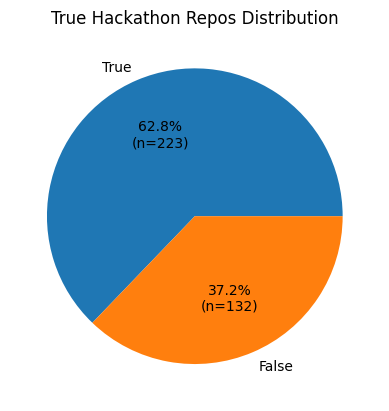

In [79]:
counts = repo_metadata_df["true_hackathon_repos"].value_counts(dropna=False)
total = counts.sum()

print("Counts:")
display(counts.rename("count").to_frame())

counts.plot(
    kind="pie",
    title="True Hackathon Repos Distribution",
    ylabel="",
    autopct=lambda p: f"{p:.1f}%\n(n={int(round(p * total / 100.0))})",
)

True hackathon repos with metadata: 195 / 223


<Axes: title={'center': 'True Hackathon Repos: Metadata Coverage'}>

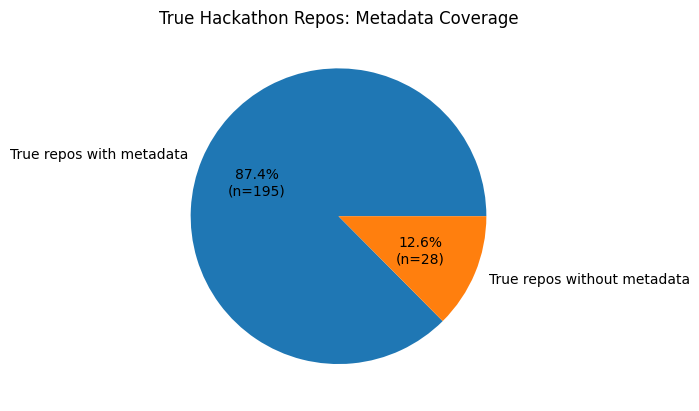

In [80]:
# Pie 2: inside true hackathon repos (with metadata vs without metadata)
if "has_valid_metadata" in repo_metadata_df.columns:
    valid_mask = repo_metadata_df["has_valid_metadata"].fillna(False).astype(bool)
else:
    valid_mask = valid_repo_metadata_mask.fillna(False).astype(bool)

true_with_meta = (true_mask & valid_mask).sum()
true_without_meta = (true_mask & ~valid_mask).sum()

true_meta_counts = pd.Series(
    {
        "True repos with metadata": int(true_with_meta),
        "True repos without metadata": int(true_without_meta),
    }
)
true_meta_total = int(true_meta_counts.sum())

print(f"True hackathon repos with metadata: {int(true_with_meta)} / {int(true_meta_total)}")

true_meta_counts.plot(
    kind="pie",
    ylabel="",
    title="True Hackathon Repos: Metadata Coverage",
    autopct=lambda p: f"{p:.1f}%\n(n={int(round(p * true_meta_total / 100.0))})",
)

true_hackathon_repos,False repos,True repos
has_ci,40.2,3.6
has_contributing,21.2,1.0
has_docker,22.0,8.2
has_docs,32.6,5.6
has_license_file,57.6,17.4
has_notebooks,10.6,17.9
has_readme_file,88.6,88.7
has_tests,19.7,3.6


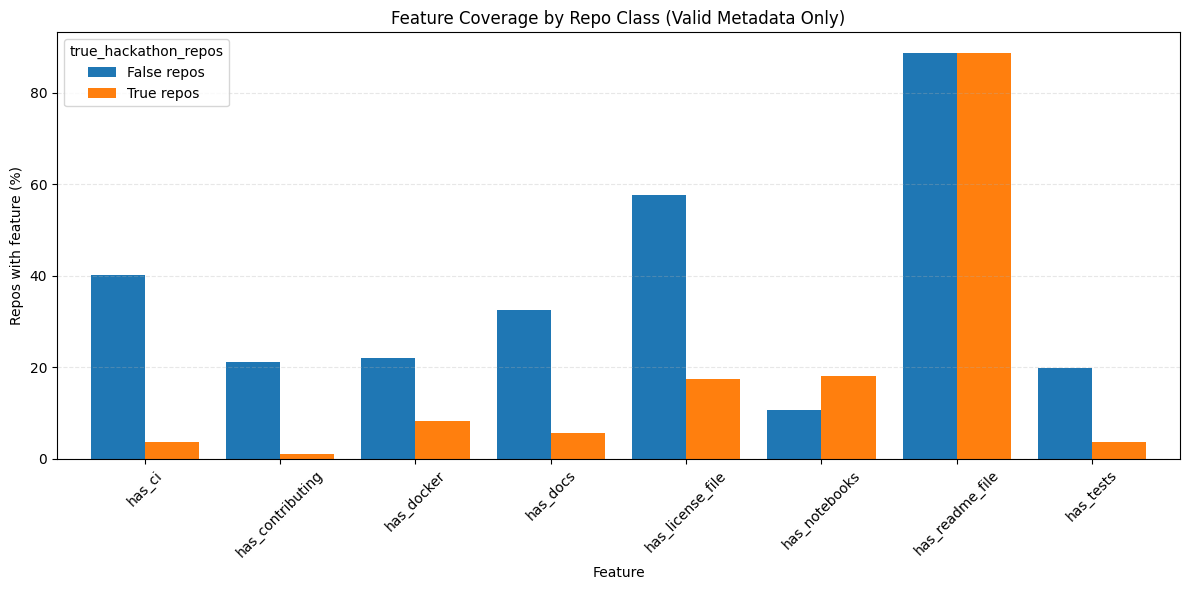

In [82]:
# Compare feature coverage (%) between true vs false hackathon repos
source_df = valid_repo_df.copy() if "valid_repo_df" in globals() else repo_metadata_df[repo_metadata_df["has_valid_metadata"]].copy()

feature_cols = [
    "has_docs",
    "has_readme_file",
    "has_tests",
    "has_license_file",
    "has_ci",
    "has_contributing",
    "has_docker",
    "has_notebooks",
]
feature_cols = [c for c in feature_cols if c in source_df.columns]

plot_df = source_df.copy()
plot_df["true_hackathon_repos"] = plot_df["true_hackathon_repos"].fillna(False).astype(bool)

for col in feature_cols:
    plot_df[col] = plot_df[col].fillna(False).astype(bool)

feature_pct = (
    plot_df.groupby("true_hackathon_repos")[feature_cols]
    .mean()
    .mul(100)
    .rename(index={False: "False repos", True: "True repos"})
    .T
    .sort_index()
)

ax = feature_pct.plot(kind="bar", figsize=(12, 6), width=0.8)
ax.set_title("Feature Coverage by Repo Class (Valid Metadata Only)")
ax.set_xlabel("Feature")
ax.set_ylabel("Repos with feature (%)")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="true_hackathon_repos")
ax.grid(axis="y", linestyle="--", alpha=0.3)

display(feature_pct.round(1))
ax.get_figure().tight_layout()

In [ ]:
# Use source_df if available, otherwise fall back to repo_metadata_df
corr_source = source_df.copy() if "source_df" in globals() else repo_metadata_df.copy()

bool_cols = corr_source.select_dtypes(include=["bool", "boolean"]).columns.tolist()
numeric_cols = corr_source.select_dtypes(include=["number"]).columns.tolist()

corr_data = corr_source[numeric_cols + bool_cols].copy()

for col in bool_cols:
    corr_data[col] = corr_data[col].astype(int)

# Drop constant columns (no variance) to avoid NaN correlations
corr_data = corr_data.loc[:, corr_data.nunique(dropna=False) > 1]

corr_matrix = corr_data.corr(method="pearson", numeric_only=True)

if corr_matrix.empty:
    raise ValueError("No columns available to plot after filtering numeric/boolean and constant columns.")

# Plot heatmap
fig_size = max(8, min(18, int(len(corr_matrix.columns) * 0.6)))
fig, ax = plt.subplots(figsize=(fig_size, fig_size))

im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Correlation Heatmap (Numeric + Boolean Columns)")
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.columns)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlation")

plt.tight_layout()
plt.show()

/var/folders/b1/02zlb8yx3m5_j30bfvwsxdr40000gn/T/ipykernel_40316/2525681143.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


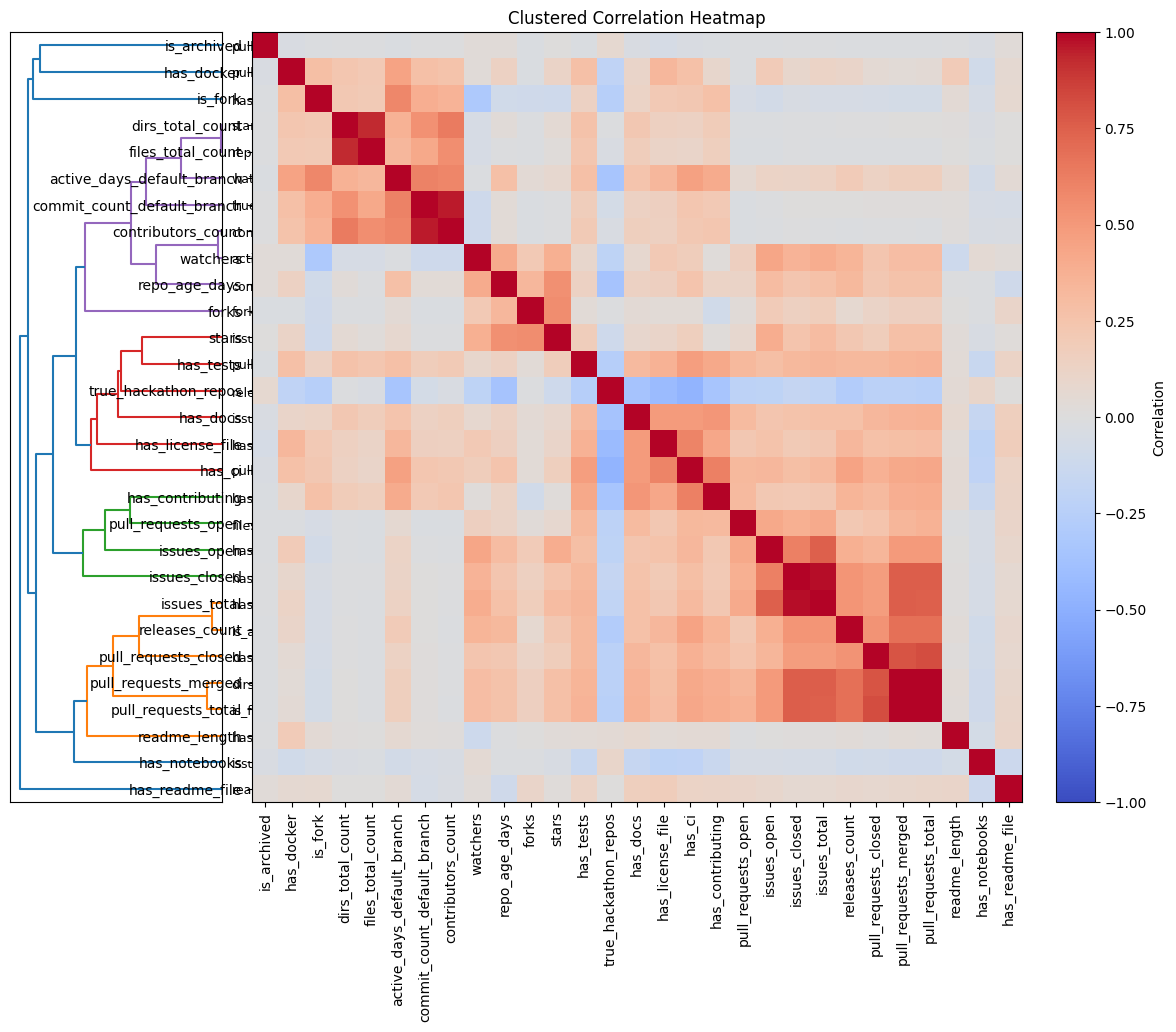

In [143]:


from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform

# Start from the same correlation-ready data
cluster_source = source_df.copy() if "source_df" in globals() else repo_metadata_df.copy()

bool_cols = cluster_source.select_dtypes(include=["bool", "boolean"]).columns.tolist()
numeric_cols = cluster_source.select_dtypes(include=["number"]).columns.tolist()

cluster_data = cluster_source[numeric_cols + bool_cols].copy()

for col in bool_cols:
    cluster_data[col] = cluster_data[col].astype(int)

# Drop constant columns
cluster_data = cluster_data.loc[:, cluster_data.nunique(dropna=False) > 1]

corr_matrix = cluster_data.corr(method="pearson", numeric_only=True)

if corr_matrix.empty:
    raise ValueError("No columns available to cluster after filtering.")

# Convert correlation to distance
distance_matrix = 1 - corr_matrix.abs()

# linkage expects condensed distance form
condensed_dist = squareform(distance_matrix.values, checks=False)
linkage_matrix = linkage(condensed_dist, method="average")

# Order columns by clustering
ordered_idx = leaves_list(linkage_matrix)
ordered_cols = corr_matrix.columns[ordered_idx]
ordered_corr = corr_matrix.loc[ordered_cols, ordered_cols]

# Figure layout: dendrogram on left, heatmap on right
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 4], wspace=0.05)

ax_dendro = fig.add_subplot(gs[0, 0])
dendrogram(
    linkage_matrix,
    orientation="left",
    labels=ordered_cols.tolist(),
    ax=ax_dendro,
    color_threshold=None,
)
ax_dendro.set_xticks([])
ax_dendro.tick_params(axis="y", labelsize=9)

ax_heat = fig.add_subplot(gs[0, 1])
im = ax_heat.imshow(ordered_corr, cmap="coolwarm", vmin=-1, vmax=1)

ax_heat.set_xticks(range(len(ordered_cols)))
ax_heat.set_yticks(range(len(ordered_cols)))
ax_heat.set_xticklabels(ordered_cols, rotation=90)
ax_heat.set_yticklabels(ordered_cols)
ax_heat.set_title("Clustered Correlation Heatmap")

cbar = plt.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04)
cbar.set_label("Correlation")

plt.tight_layout()
plt.show()

In [ ]:
target_col = "true_hackathon_repos"
target_source = source_df.copy() if "source_df" in globals() else repo_metadata_df.copy()

bool_cols = target_source.select_dtypes(include=["bool", "boolean"]).columns.tolist()
numeric_cols = target_source.select_dtypes(include=["number"]).columns.tolist()

target_data = target_source[numeric_cols + bool_cols].copy()

for col in bool_cols:
    target_data[col] = target_data[col].astype(int)

target_data = target_data.loc[:, target_data.nunique(dropna=False) > 1]

if target_col not in target_data.columns:
    raise ValueError(f"{target_col} is not available for correlation plotting.")

target_corr = (
    target_data.corr(method="pearson", numeric_only=True)[target_col]
    .drop(target_col)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

if target_corr.empty:
    raise ValueError("No usable feature correlations found for the target.")

plot_matrix = target_corr.to_frame(name="Correlation with true_hackathon_repos")

fig_h = max(6, len(plot_matrix) * 0.35)
fig, ax = plt.subplots(figsize=(6, fig_h))

im = ax.imshow(plot_matrix.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks([0])
ax.set_xticklabels(["true_hackathon_repos"])
ax.set_yticks(range(len(plot_matrix.index)))
ax.set_yticklabels(plot_matrix.index, fontsize=9)
ax.set_title("Feature Correlation with true_hackathon_repos")

for i, value in enumerate(plot_matrix["Correlation with true_hackathon_repos"]):
    ax.text(
        0,
        i,
        f"{value:.2f}",
        ha="center",
        va="center",
        color="black",
        fontsize=8,
    )

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlation")

plt.tight_layout()
plt.show()

Dendogram based heatmap

In [135]:
target = "true_hackathon_repos"

corr_df = repo_metadata_df.copy()
bool_cols = corr_df.select_dtypes(include=["bool", "boolean"]).columns
corr_df[bool_cols] = corr_df[bool_cols].astype(int)

numeric_cols = corr_df.select_dtypes(include=["number"]).columns
target_corr = (
    corr_df[numeric_cols]
    .corr()[target]
    .drop(target)
    .abs()
    .sort_values(ascending=False)
)

target_corr.head(20)


KeyError: 'true_hackathon_repos'

In [ ]:
# 6. License distribution (top 8)
# Use available SPDX column (fallback to `license_spdx`) to avoid KeyError
license_col = (
    "repo_license_spdx" if "repo_license_spdx" in repo_metadata_df.columns
    else "license_spdx" if "license_spdx" in repo_metadata_df.columns
    else None
)

if license_col is None:
    license_counts = pd.Series({"Unknown": len(repo_metadata_df)})
else:
    license_counts = (
        repo_metadata_df[license_col]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
        .fillna("Unknown")
        .value_counts()
        .head(8)
    )

fig, ax = plt.subplots(figsize=(8, 6))

# Recompute license distribution using only repos with valid metadata
if "has_valid_metadata" in repo_metadata_df.columns:
    metadata_mask = repo_metadata_df["has_valid_metadata"].fillna(False).astype(bool)
elif "valid_repo_metadata_mask" in globals():
    metadata_mask = valid_repo_metadata_mask.fillna(False).astype(bool)
else:
    metadata_mask = repo_metadata_df["url"].fillna("").ne("") & repo_metadata_df["error"].fillna("").eq("")

metadata_df = repo_metadata_df.loc[metadata_mask].copy()

if license_col is None:
    license_counts = pd.Series({"Unknown": len(metadata_df)})
else:
    license_counts = (
        metadata_df[license_col]
        .astype("string")
        .str.strip()
        .replace("", pd.NA)
        .fillna("Unknown")
        .value_counts()
        .head(8)
    )

total_licenses = int(license_counts.sum())

def _autopct_with_counts(pct):
    count = int(round((pct / 100.0) * total_licenses))
    return f"{pct:.1f}%\n(n={count})"

ax.pie(
    license_counts.values,
    labels=license_counts.index,
    autopct=_autopct_with_counts,
    startangle=140,
    textprops={"fontsize": 9},
)
ax.set_title("License Distribution (Top 8, Valid Metadata Only)")
ax.axis("equal")

plt.suptitle('Repo-Level Overview', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 programming languages: hackathon vs non-hackathon
lang_source = (
    source_df.copy()
    if "source_df" in globals()
    else valid_repo_df.copy()
    if "valid_repo_df" in globals()
    else repo_metadata_df.copy()
)

required_cols = ["primary_language", "true_hackathon_repos"]
missing = [c for c in required_cols if c not in lang_source.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

tmp = lang_source.copy()
tmp["primary_language"] = (
    tmp["primary_language"]
    .astype("string")
    .str.strip()
    .replace("", pd.NA)
)
tmp["repo_class"] = tmp["true_hackathon_repos"].fillna(False).astype(bool).map(
    {True: "Hackathon", False: "Non-hackathon"}
)

lang_counts = (
    tmp.dropna(subset=["primary_language"])
    .groupby(["primary_language", "repo_class"])
    .size()
    .unstack(fill_value=0)
)

top10_langs = lang_counts.sum(axis=1).sort_values(ascending=False).head(10).index
plot_df = lang_counts.loc[top10_langs].sort_values(by=lang_counts.columns.tolist(), ascending=True)

ax = plot_df.plot(kind="barh", figsize=(10, 6), width=0.85)
ax.set_title("Top 10 Programming Languages: Hackathon vs Non-hackathon")
ax.set_xlabel("Repository Count")
ax.set_ylabel("Language")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend(title="Repo Class")

plt.tight_layout()
plt.show()

propotion basesd for this kind of visulas

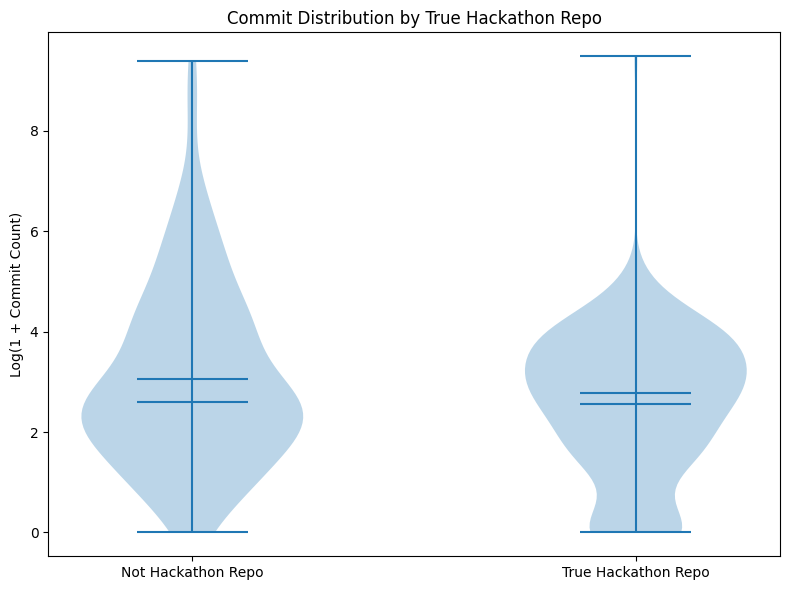

In [104]:
plot_df = repo_metadata_df.copy()

group0 = plot_df.loc[plot_df["true_hackathon_repos"] == 0, "commit_log"].dropna()
group1 = plot_df.loc[plot_df["true_hackathon_repos"] == 1, "commit_log"].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
parts = ax.violinplot([group0, group1], showmeans=True, showmedians=True)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Not Hackathon Repo", "True Hackathon Repo"])
ax.set_ylabel("Log(1 + Commit Count)")
ax.set_title("Commit Distribution by True Hackathon Repo")

plt.tight_layout()
plt.show()

Interpretation:
- if the hackathon violin is concentrated low on the y-axis, most hackathon repos have relatively few commits
- if it is taller and more spread out, hackathon repos vary a lot in activity
- if the non-hackathon violin extends much higher, those repos tend to include more heavily developed projects
- if one group has a much higher median, that group is typically more active
- because it’s log-scaled, differences are compressed, so very large commit counts don’t dominate the chart

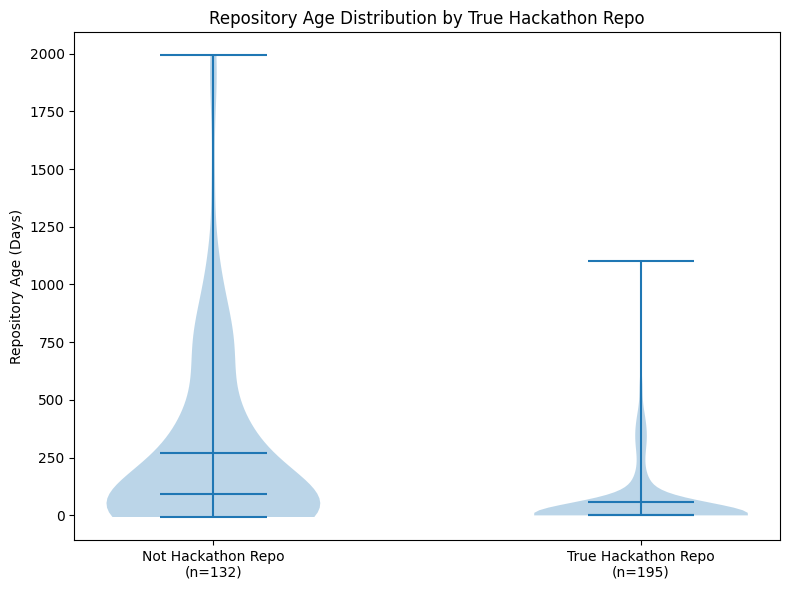

In [110]:
plot_df = repo_metadata_df.copy()

group0 = plot_df.loc[plot_df["true_hackathon_repos"] == 0, "repo_age_days"].dropna()
group1 = plot_df.loc[plot_df["true_hackathon_repos"] == 1, "repo_age_days"].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
ax.violinplot([group0, group1], showmeans=True, showmedians=True)

ax.set_xticks([1, 2])
ax.set_xticklabels([
    f"Not Hackathon Repo\n(n={len(group0)})",
    f"True Hackathon Repo\n(n={len(group1)})"
])
ax.set_ylabel("Repository Age (Days)")
ax.set_title("Repository Age Distribution by True Hackathon Repo")

plt.tight_layout()
plt.show()

##### Now analyse the concepts

In [ ]:
import ast

top_n = 10
concept_source = repo_metadata_df.copy()

required_cols = ["true_hackathon_repos"]
missing = [c for c in required_cols if c not in concept_source.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

if "repo_concept_names" not in concept_source.columns and "repo_top_concept" not in concept_source.columns:
    raise KeyError("Need either 'repo_concept_names' or 'repo_top_concept' in repo_metadata_df.")

def _to_list(v):
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return []
    if isinstance(v, list):
        return [str(x).strip() for x in v if str(x).strip()]
    if isinstance(v, str):
        s = v.strip()
        if not s:
            return []
        try:
            parsed = json.loads(s)
            if isinstance(parsed, list):
                return [str(x).strip() for x in parsed if str(x).strip()]
            if isinstance(parsed, str) and parsed.strip():
                return [parsed.strip()]
        except Exception:
            pass
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(x).strip() for x in parsed if str(x).strip()]
            if isinstance(parsed, str) and parsed.strip():
                return [parsed.strip()]
        except Exception:
            pass
        return [s]
    return [str(v).strip()] if str(v).strip() else []

if "repo_concept_names" in concept_source.columns:
    concept_source["concept_list"] = concept_source["repo_concept_names"].map(_to_list)
else:
    concept_source["concept_list"] = concept_source["repo_top_concept"].map(_to_list)

if "repo_top_concept" in concept_source.columns:
    top_fallback = concept_source["repo_top_concept"].map(_to_list)
    concept_source["concept_list"] = [
        concepts if len(concepts) > 0 else fallback
        for concepts, fallback in zip(concept_source["concept_list"], top_fallback)
    ]

concept_long = (
    concept_source.assign(
        repo_class=concept_source["true_hackathon_repos"].fillna(False).astype(bool).map(
            {True: "Hackathon", False: "Non-hackathon"}
        )
    )
    .explode("concept_list")
    .rename(columns={"concept_list": "concept"})
)

concept_long["concept"] = concept_long["concept"].astype("string").str.strip()
concept_long = concept_long.dropna(subset=["concept"])
concept_long = concept_long[concept_long["concept"].ne("")]

top_hackathon = concept_long.loc[concept_long["repo_class"] == "Hackathon", "concept"].value_counts().tail(top_n)
top_non_hackathon = concept_long.loc[concept_long["repo_class"] == "Non-hackathon", "concept"].value_counts().tail(top_n)

print(f"Top {top_n} concepts — Hackathon repos")
display(top_hackathon.rename("count").to_frame())

print(f"Top {top_n} concepts — Non-hackathon repos")
display(top_non_hackathon.rename("count").to_frame())

In [ ]:
# Concept coverage + distribution focused on "few-project" concepts

concept_df = repo_metadata_df.copy()

if "repo_concept_names" in concept_df.columns:
    concept_col = "repo_concept_names"
elif "repo_top_concept" in concept_df.columns:
    concept_col = "repo_top_concept"
else:
    if "topics" in concept_df.columns:
        concept_col = "topics"
        print("Falling back to 'topics' as concept source.")
    else:
        raise KeyError(
            "Need one of ['repo_concept_names', 'repo_top_concept', 'topics'] in repo_metadata_df."
        )

concept_df["concept_list"] = concept_df[concept_col].map(_to_list)

# Project key preferred for "shared by projects", fallback to repo_url
if "project_foreign_key" in concept_df.columns:
    project_key = concept_df["project_foreign_key"].astype("string").fillna("").str.strip()
    concept_df["project_id"] = project_key.mask(project_key.eq(""), concept_df["repo_url"].astype("string"))
else:
    concept_df["project_id"] = concept_df["repo_url"].astype("string")

if "true_hackathon_repos" not in concept_df.columns:
    if "repo_class" in concept_df.columns:
        concept_df["true_hackathon_repos"] = (
            concept_df["repo_class"].astype("string").str.strip().str.lower().eq("hackathon")
        )
    else:
        concept_df["true_hackathon_repos"] = False

concept_long = (
    concept_df[["repo_url", "project_id", "true_hackathon_repos", "concept_list"]]
    .explode("concept_list")
    .rename(columns={"concept_list": "concept"})
)
concept_long["concept"] = concept_long["concept"].astype("string").str.strip()
concept_long = concept_long.dropna(subset=["concept"])
concept_long = concept_long[concept_long["concept"].ne("")]

total_repos = concept_df["repo_url"].nunique()
repos_with_concepts = concept_df["concept_list"].map(len).gt(0).sum()
total_mentions = len(concept_long)
unique_concepts = concept_long["concept"].nunique()

print(f"Total repos: {total_repos}")
print(f"Repos with >=1 concept: {repos_with_concepts} ({repos_with_concepts / total_repos:.1%})")
print(f"Total concept mentions (repo-level): {total_mentions}")
print(f"Unique concepts: {unique_concepts}")

concept_stats = (
    concept_long.groupby("concept")
    .agg(
        unique_projects=("project_id", "nunique"),
        unique_repos=("repo_url", "nunique"),
        hackathon_repos=("true_hackathon_repos", lambda s: int((s.fillna(False).astype(bool)).sum())),
        non_hackathon_repos=("true_hackathon_repos", lambda s: int((~s.fillna(False).astype(bool)).sum())),
    )
    .sort_values(["unique_projects", "unique_repos"], ascending=False)
)

# Frequency buckets by number of projects
bins = [0, 1, 3, 5, 10, 25, np.inf]
labels = ["1", "2-3", "4-5", "6-10", "11-25", "26+"]
concept_stats["project_freq_bucket"] = pd.cut(
    concept_stats["unique_projects"], bins=bins, labels=labels, include_lowest=True
)

bucket_summary = (
    concept_stats["project_freq_bucket"]
    .value_counts(sort=False)
    .rename_axis("projects_with_concept")
    .reset_index(name="n_concepts")
)

print("\nConcept frequency buckets (by unique projects):")
display(bucket_summary)

# Focus region: concepts shared by a few projects (2 to 5)
few_project_concepts = concept_stats.query("2 <= unique_projects <= 5").copy()
few_project_concepts["hackathon_share"] = (
    few_project_concepts["hackathon_repos"] /
    (few_project_concepts["hackathon_repos"] + few_project_concepts["non_hackathon_repos"]).replace(0, np.nan)
)

print(f"\nConcepts shared by a few projects (2-5): {len(few_project_concepts)}")
display(
    few_project_concepts
    .sort_values(["unique_projects", "unique_repos", "hackathon_share"], ascending=[False, False, False])
    .head(30)
)

# Optional: inspect mid-frequency concepts (not most common, not singletons)
mid_frequency = concept_stats.query("4 <= unique_projects <= 10").copy()
print(f"\nMid-frequency concepts (4-10 projects): {len(mid_frequency)}")
display(mid_frequency.sort_values("unique_projects", ascending=False).head(20))

In [ ]:
# Add concept-frequency buckets back onto repo_metadata_df (repo-level columns)

# 1) pick concept source
if "repo_concept_names" in repo_metadata_df.columns:
    concept_col = "repo_concept_names"
elif "repo_top_concept" in repo_metadata_df.columns:
    concept_col = "repo_top_concept"
elif "topics" in repo_metadata_df.columns:
    concept_col = "topics"
else:
    raise KeyError("Need one of: repo_concept_names, repo_top_concept, topics")


def _bucket_label_from_count(value):
    if pd.isna(value):
        return pd.NA
    value = float(value)
    if value <= 1:
        return "1"
    if value <= 3:
        return "2-3"
    if value <= 5:
        return "4-5"
    if value <= 10:
        return "6-10"
    if value <= 25:
        return "11-25"
    return "26+"


def _normalize_bucket_list(values):
    cleaned = []
    for value in values:
        if pd.isna(value):
            continue
        label = str(value).strip()
        if label and label not in cleaned:
            cleaned.append(label)
    return cleaned


def _fill_bucket_list_from_min_max(row):
    buckets = row["concept_project_freq_buckets"]
    if isinstance(buckets, list) and buckets:
        return buckets

    inferred = []
    for col in ["min_concept_projects", "max_concept_projects"]:
        label = _bucket_label_from_count(row[col])
        if pd.notna(label) and label not in inferred:
            inferred.append(label)

    return inferred if inferred else pd.NA


tmp_df = repo_metadata_df.copy()
tmp_df["concept_list"] = tmp_df[concept_col].map(_to_list)

# 2) project key (same logic as your concept analysis cell)
if "project_foreign_key" in tmp_df.columns:
    proj_key = tmp_df["project_foreign_key"].astype("string").fillna("").str.strip()
    tmp_df["project_id"] = proj_key.mask(proj_key.eq(""), tmp_df["repo_url"].astype("string"))
else:
    tmp_df["project_id"] = tmp_df["repo_url"].astype("string")

# 3) concept -> unique project counts -> bucket
long_df = (
    tmp_df[["repo_url", "project_id", "concept_list"]]
    .explode("concept_list")
    .rename(columns={"concept_list": "concept"})
)
long_df["concept"] = long_df["concept"].astype("string").str.strip()
long_df = long_df.dropna(subset=["concept"])
long_df = long_df[long_df["concept"].ne("")]

concept_project_counts = (
    long_df.groupby("concept", as_index=False)["project_id"]
    .nunique()
    .rename(columns={"project_id": "concept_unique_projects"})
)
concept_project_counts["concept_project_freq_bucket"] = concept_project_counts[
    "concept_unique_projects"
].map(_bucket_label_from_count).astype("string")

# 4) map bucket info back to each repo
repo_bucket_long = long_df.merge(concept_project_counts, on="concept", how="left")

repo_bucket_agg = (
    repo_bucket_long.groupby("repo_url", as_index=False)
    .agg(
        concept_project_freq_buckets=(
            "concept_project_freq_bucket",
            _normalize_bucket_list,
        ),
        min_concept_projects=(
            "concept_unique_projects",
            "min",
        ),
        max_concept_projects=(
            "concept_unique_projects",
            "max",
        ),
    )
)

repo_bucket_agg["concept_project_freq_buckets"] = repo_bucket_agg.apply(
    _fill_bucket_list_from_min_max,
    axis=1,
)

bucket_cols = [
    "concept_project_freq_buckets",
    "min_concept_projects",
    "max_concept_projects",
]
repo_metadata_df = repo_metadata_df.drop(columns=bucket_cols, errors="ignore")
repo_metadata_df = repo_metadata_df.merge(repo_bucket_agg, on="repo_url", how="left")

print("Added columns:")
print(bucket_cols)
repo_metadata_df[["repo_url", "concept_project_freq_buckets", "min_concept_projects", "max_concept_projects"]]

In [175]:
repo_metadata_df

,repo_url,commit_count_default_branch,contributors_count,contributors_top,created_at,default_branch,description,dirs_total_count,files_root_entries,files_total_count,...,error,concept_project_freq_buckets_x,min_concept_projects_x,max_concept_projects_x,concept_project_freq_buckets_y,min_concept_projects_y,max_concept_projects_y,concept_project_freq_buckets,min_concept_projects,max_concept_projects
0,https://github.com/22cav/lauzhack2025,21,4,"[{'contributions': 14, 'html_url': 'https://gi...",2025-11-22 13:18:04+00:00,lauzhack2025,Control Blender in real-time with hand gestures,19,"[{'path': '.gitignore', 'size': 485, 'type': '...",76,...,,['1'],1.0,1.0,['1'],1.0,1.0,[1],1.0,1.0
1,https://github.com/4cademy/I.R.I.S._LauzHack_2024,41,4,"[{'contributions': 24, 'html_url': 'https://gi...",2024-11-30 13:21:59+00:00,main,Our project for the Vitol challenge at LauzHac...,1,"[{'path': '.DS_Store', 'size': 6148, 'type': '...",13,...,,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN
2,https://github.com/ALIANTE-IoT/ALIANTE,29,5,"[{'contributions': 13, 'html_url': 'https://gi...",2025-11-22 11:25:55+00:00,main,A distributed system for automated biodiversit...,24,"[{'path': '.gitignore', 'size': 2251, 'type': ...",73,...,,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN
3,https://github.com/AaronDinesh/lauzhack-2025,109,4,"[{'contributions': 49, 'html_url': 'https://gi...",2025-11-22 10:46:30+00:00,main,,19,"[{'path': '.gitignore', 'size': 5201, 'type': ...",66,...,,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN
4,https://github.com/Akbermet-Toktobekova/Lauz_h...,9,2,"[{'contributions': 8, 'html_url': 'https://git...",2025-11-22 20:56:29+00:00,main,,17,"[{'path': '.gitignore', 'size': 953, 'type': '...",123,...,,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350,https://github.com/walid-as/sbb-ghost-rider,4,2,"[{'contributions': 3, 'html_url': 'https://git...",2025-11-22 14:51:40+00:00,main,LauzHack challenge 2025:,34,"[{'path': '.gitignore', 'size': 225, 'type': '...",69,...,,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN
351,https://github.com/wesleymth/LauzHack2023-Auto...,65,4,"[{'contributions': 30, 'html_url': 'https://gi...",2023-05-14 20:39:18+00:00,main,,1,"[{'path': '.gitignore', 'size': 3151, 'type': ...",23,...,,<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN
352,https://github.com/wesleymth/Lauzhack-2024-Cou...,0,0,NaN,NaT,,,0,NaN,0,...,"[{'type': 'NOT_FOUND', 'path': ['repository'],...",<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN
353,https://github.com/youssefouru/LauzHack,0,0,NaN,NaT,,,0,NaN,0,...,"[{'type': 'NOT_FOUND', 'path': ['repository'],...",<NA>,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN


## Predict Hackathon Repos

In [176]:
def is_hackathon_repo(df: pd.DataFrame, output_type: str = "category") -> pd.DataFrame:
    """
    Rule-based confidence flagging using only repo descriptive fields + repo stats.

    Returns:
    - hackathon_repo_flag: certain | uncertain | unlikely
    - hackathon_repo_score: numeric rule score
    - hackathon_repo_signals: explanation string
    """
    out = df.copy()

    def _topics_to_text(v) -> str:
        if v is None:
            return ""
        if isinstance(v, list):
            return " ".join(str(x) for x in v if x is not None)
        if isinstance(v, str):
            s = v.strip()
            if not s:
                return ""
            try:
                parsed = json.loads(s)
                if isinstance(parsed, list):
                    return " ".join(str(x) for x in parsed if x is not None)
            except Exception:
                pass
            return s
        return str(v)

    # Repo description-style signals only.
    strong_terms = ["hackathon", "lauzhack", "devpost", "mlh", "major league hacking", "hackerearth", "hackerone", "hackathon.com"]
    weak_terms = ["prototype", "weekend project", "submission", "challenge", "demo", "pitch", "built in 24 hours", "built in 48 hours", "built in 72 hours"]

    def get_num(v):
        try:
            return float(v)
        except Exception:
            return 0.0

    scores = []
    flags = []
    reasons = []

    for _, r in out.iterrows():
        text_blob = " ".join([
            str(r.get("repo_url", "") or ""),
            str(r.get("repo_name", "") or ""),
            str(r.get("primary_language", "") or ""),
            str(r.get("readme_title", "") or ""),
            str(r.get("readme_text", "") or ""),
            _topics_to_text(r.get("repo_topics")),
        ]).lower()

        score = 0
        row_reasons = []

        if any(t in text_blob for t in strong_terms):
            score += 3
            row_reasons.append("strong_repo_text")
        elif any(t in text_blob for t in weak_terms):
            score += 1
            row_reasons.append("weak_repo_text")

        stars = get_num(r.get("stars"))
        forks = get_num(r.get("forks"))
        contributors = get_num(r.get("contributors_count"))
        commits = get_num(r.get("commit_count_default_branch"))

        if stars >= 1 or forks >= 1:
            score += 1
            row_reasons.append("repo_popularity_signal")

        if contributors >= 2:
            score += 1
            row_reasons.append("contributors_signal")

        if commits >= 5:
            score += 1
            row_reasons.append("commit_activity_signal")

        active_days = get_num(r.get("active_days_default_branch"))
        if active_days > 0 and active_days <= 3:
            score += 2
            row_reasons.append("burst_commit_window_strong")
        elif active_days > 0 and active_days <= 7:
            score += 1
            row_reasons.append("burst_commit_window_weak")

        if r.get("repo_error") and score == 0:
            score -= 1
            row_reasons.append("metadata_error")
        
        if output_type == "bool":
            if score >= 4:
                flag = True
            else:
                flag = False
        else:
            if score >= 4:
                flag = "certain"
            elif score >= 2:
                flag = "uncertain"
            else:
                flag = "unlikely"

        scores.append(score)
        flags.append(flag)
        reasons.append("|".join(row_reasons) if row_reasons else "no_signal")

    out["repo_predicted_score"] = scores
    out["repo_predicted_flag"] = flags
    out["repo_predicted_signals"] = reasons
    return out


repo_metadata_df = is_hackathon_repo(repo_metadata_df, output_type="bool")
repo_metadata_df["repo_predicted_flag"].value_counts(dropna=False)

repo_predicted_flag
False    230
True     125
Name: count, dtype: int64

In [177]:
cm_df = repo_metadata_df.dropna(subset=["repo_predicted_flag", "true_hackathon_repos"]).copy()

y_true = cm_df["true_hackathon_repos"].astype(int)
y_pred = cm_df["repo_predicted_flag"].astype(int)

tp = ((y_true == 1) & (y_pred == 1)).sum()
tn = ((y_true == 0) & (y_pred == 0)).sum()
fp = ((y_true == 0) & (y_pred == 1)).sum()
fn = ((y_true == 1) & (y_pred == 0)).sum()

conf_matrix = pd.DataFrame(
    [[tn, fp],
     [fn, tp]],
    index=["Actual: False", "Actual: True"],
    columns=["Pred: False", "Pred: True"]
)

display(conf_matrix)

KeyError: ['true_hackathon_repos']

Accuracy: 0.662
Precision: 0.912
Recall: 0.511
F1: 0.655


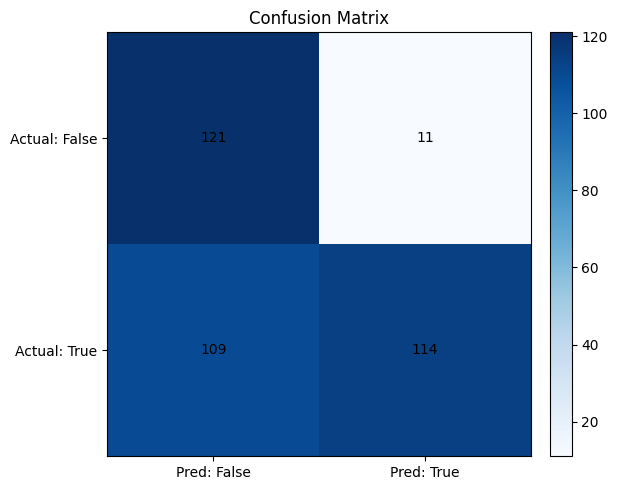

In [125]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1:", round(f1, 3))

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(conf_matrix.values, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(conf_matrix.columns)
ax.set_yticklabels(conf_matrix.index)
ax.set_title("Confusion Matrix")

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(j, i, conf_matrix.iloc[i, j], ha="center", va="center", color="black")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

- Some of actual true are not actually true because some repos were part of organization but didn't have hackathon type activity
- When calculating the score, we have to add more factors that contribute to the confidence score, and also assign different weights to different factors. For example, if a repo has a hackathon-related topic, that should contribute more to the score than just having a certain number of commits. Current logic is a basic method to predict the hackathon vs non-hackathon repos, but we can improve it by adding more features and assigning different weights to them.
- We can also consider using a machine learning model to predict whether a repo is a hackathon repo or not, based on the features we have extracted. This would allow us to capture more complex relationships between the features and the target variable, and potentially improve our predictions.

In [146]:
repo_metadata_df.to_csv(DATA_ROOT / "repo_metadata_with_predictions.csv", index=False)